In [1]:
import os
from pathlib import Path
from pprint import pprint

#import matplotlib
#matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from model_tuner.opt.regimes import (
    PopRegime1D, NetRegime1D, NetRegime1DList)
from model_tuner.opt.inputs import (
    PopInputND, NetInputND)
from model_tuner.opt.ir_mappers import NetIRMapper1DInterp
from model_tuner.main import IRMapConfigRateInterpFrom2DXR
from model_tuner.utils import (
    load_yaml, plot_xr, plot_xr_contour)


c:\Users\aleks\.conda\envs\netpyne_batch\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [4]:
dirpath_base = Path(r'D:\WORK\Salvador\repo\model_tuner\opt_experiments\ou_surr_to_full'
                    r'\data\exp_ou_full_state1_mech1_nosub_wmult_0.1')

fpath_ir_params = dirpath_base / 'test_dummy_1' / 'ir_map_params.yaml'
ir_params = load_yaml(fpath_ir_params, data_class=IRMapConfigRateInterpFrom2DXR)

ir_params.smooth_sigma['v_med_min'] = 1.5
ir_params.smooth_sigma['v_med_max'] = 1.5

net_ir_mapper, rate_mats = ir_params.init_ir_mapper()


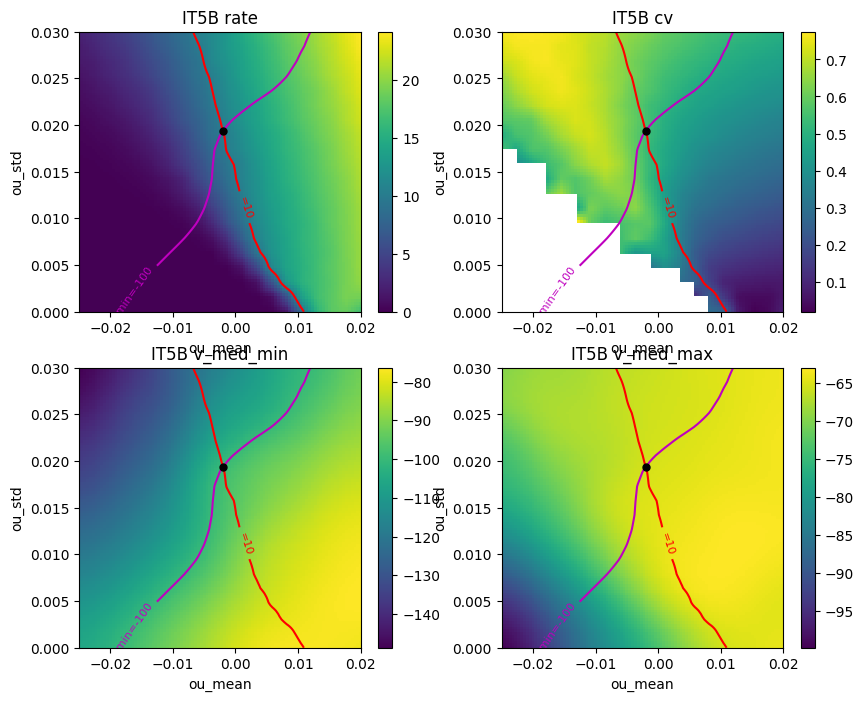

In [5]:
pop = 'IT5B'
R = PopRegime1D(10)

pop_ir_mapper = net_ir_mapper[pop]
D = pop_ir_mapper.maps2d
r0 = R.value

I = pop_ir_mapper.R_to_I(R)

if pop_ir_mapper.interp_method == 'vmin_eq':
    vmin_vis = np.sort(pop_ir_mapper.interp_params['vmin_vals'])
else:
    vmin_vis = [-150]

plt.figure(figsize=(10, 8))
for n, (v, X_) in enumerate(D.items()):
    plt.subplot(2, 2, n + 1)
    plot_xr(X_, show_ax_names=True)
    plot_xr_contour(D['rate'], '', [r0], colors=['r'])
    plot_xr_contour(D['cv'], 'cv', [1], colors=['k'])
    plot_xr_contour(D['v_med_min'], 'vmin', vmin_vis, colors=['m'])
    plt.plot(I['ou_mean'], I['ou_std'], 'k.', markersize=10)
    plt.title(f'{pop} {v}')
plt.show()